<a href="https://colab.research.google.com/github/crce9830ecs-lang/aiml_labs/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
#loading the dataset
import kagglehub

path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Dataset downloaded to:", path)

import os
print(os.listdir(path))

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Dataset downloaded to: /kaggle/input/breast-cancer-wisconsin-data
['data.csv']


In [23]:
# Install KaggleHub if needed
!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# File inside the Kaggle dataset
file_path = "data.csv"

# Load dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uciml/breast-cancer-wisconsin-data",
    file_path,
)

print("First 5 records:")
print(df.head())

print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns)

/tmp/ipykernel_13570/4282246111.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
First 5 records:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280    

In [24]:
#preporcessing
print("Dataset Shape:", df.shape)

print("\nFirst 10 rows:")
display(df.head(10))

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (569, 33)

First 10 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN



Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavi

In [25]:
#cheching for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_

In [26]:
#check for total missing values
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)


Total missing values: 569


In [27]:


# Drop the column containing missing values
df = df.drop(columns=["Unnamed: 32"])

print("Columns after removing unnecessary column:")
print(df.columns)

print("\nTotal missing values:", df.isnull().sum().sum())

Columns after removing unnecessary column:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

Total missing values: 0


In [28]:
print("Columns after removing unnecessary columns:")
print(df.columns)

print("\nShape:", df.shape)

Columns after removing unnecessary columns:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

Shape: (569, 32)


In [29]:
#checking for missing values after dropping the column
print("Missing values after cleaning:")

missing = df.isnull().sum()
print(missing[missing > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values after cleaning:
Series([], dtype: int64)

Total missing values: 0


In [30]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [31]:
#convert the M = Malignant=1 B = Benign =0
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

print(df["diagnosis"].value_counts())


diagnosis
0    357
1    212
Name: count, dtype: int64


In [32]:
print(df.head())
print(df.dtypes)


         id  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302          1        17.99         10.38          122.80     1001.0   
1    842517          1        20.57         17.77          132.90     1326.0   
2  84300903          1        19.69         21.25          130.00     1203.0   
3  84348301          1        11.42         20.38           77.58      386.1   
4  84358402          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  ar

In [33]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 31)
y shape: (569,)


In [34]:
#splitting the data into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 31)
X_test: (114, 31)
y_train: (455,)
y_test: (114,)


In [35]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (455, 31)
X_test_scaled shape: (114, 31)


In [36]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [37]:
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree predictions:")
print(y_pred_dt)

Decision Tree predictions:
[0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0
 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 1 0 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 1 1]


In [38]:
#results
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree Results
---------------------
Accuracy : 0.9210526315789473
Precision: 0.9024390243902439
Recall   : 0.8809523809523809
F1 Score : 0.891566265060241


Confusion Matrix:
[[68  4]
 [ 5 37]]


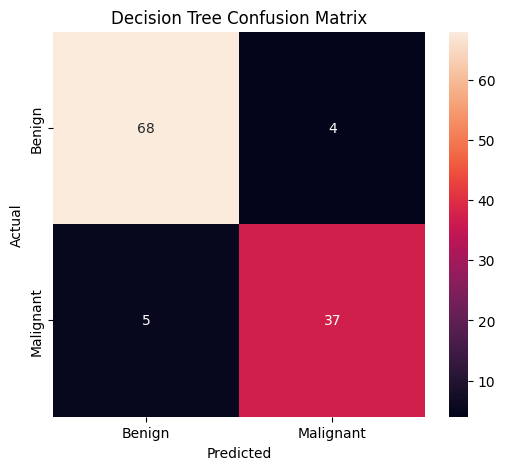

In [39]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [40]:
#logistic regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [41]:
y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression predictions:")
print(y_pred_lr)

Logistic Regression predictions:
[0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 0 1]


In [42]:
#results
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("--------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

Logistic Regression Results
--------------------------
Accuracy : 0.9649122807017544
Precision: 0.975
Recall   : 0.9285714285714286
F1 Score : 0.9512195121951219


Confusion Matrix:
[[71  1]
 [ 3 39]]


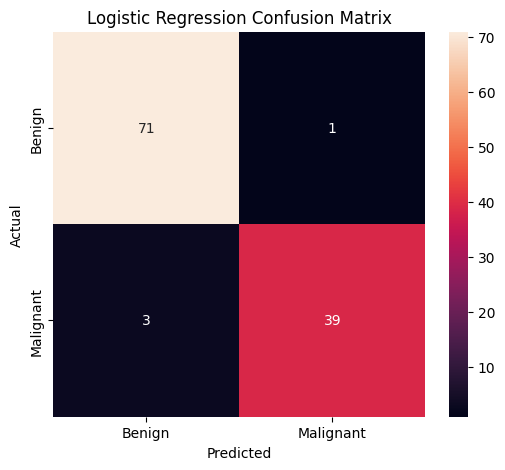

In [43]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [44]:
#comparing both the models
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Decision Tree": [
        accuracy_dt,
        precision_dt,
        recall_dt,
        f1_dt
    ],
    "Logistic Regression": [
        accuracy_lr,
        precision_lr,
        recall_lr,
        f1_lr
    ]
})

comparison_display = comparison.copy()

comparison_display["Decision Tree"] = (
    comparison_display["Decision Tree"] * 100
).round(2)

comparison_display["Logistic Regression"] = (
    comparison_display["Logistic Regression"] * 100
).round(2)

print(comparison_display)

      Metric  Decision Tree  Logistic Regression
0   Accuracy          92.11                96.49
1  Precision          90.24                97.50
2     Recall          88.10                92.86
3   F1 Score          89.16                95.12
